# AF5344 Group Project — Short Book Research & Selection

## Equity Long/Short Fund — HSI Universe

This notebook performs systematic screening of Hang Seng Index (HSI) constituents to select **10+ stocks for the Short Book**.

### Screening Criteria for Shorts:
| Metric | Threshold | Rationale |
|--------|-----------|----------|
| ROE | < 8% or declining | Poor capital efficiency |
| Earnings Growth | Negative or revisions down | Deteriorating profitability |
| P/E Ratio | > Sector Median (if profitable) | Overvalued vs weak fundamentals |
| Debt/Equity | > 150% | High leverage amplifies downside |
| 6-Month Momentum | Negative | Price trend confirms weakness |
| Beta (β) | > 1.0 (preferred) | Higher beta = more downside in corrections |
| Alpha (α) | < 0 | Negative excess return vs benchmark |
| R-squared (R²) | 0.3 – 0.9 | Meaningful market relationship |
| Sector Headwinds | Qualitative assessment | Regulatory/structural pressures |

---
## 1. Setup & Install Dependencies

In [1]:
# Install required packages (run once)
#!pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels --quiet

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("All packages loaded successfully.")

All packages loaded successfully.


---
## 2. Define HSI Constituent Universe

**Same universe as the Long Book notebook.** All 88 HSI constituents.

In [3]:
# HSI Constituents — Full 88-stock list (Feb 2026)
# Format: (Stock Code, Yahoo Ticker, Company Name, Sector, HSI Weight %)

hsi_constituents = [
    # === Top 50 by weight (from HSI factsheet) ===
    ('0005', '0005.HK', 'HSBC Holdings', 'Financials', 10.47),
    ('9988', '9988.HK', 'Alibaba Group', 'Consumer Discretionary', 7.18),
    ('0700', '0700.HK', 'Tencent Holdings', 'Information Technology', 6.63),
    ('1299', '1299.HK', 'AIA Group', 'Financials', 5.52),
    ('0939', '0939.HK', 'China Construction Bank', 'Financials', 4.65),
    ('1810', '1810.HK', 'Xiaomi Corp', 'Information Technology', 3.85),
    ('1398', '1398.HK', 'ICBC', 'Financials', 3.22),
    ('0388', '0388.HK', 'HK Exchanges & Clearing', 'Financials', 3.05),
    ('0941', '0941.HK', 'China Mobile', 'Telecommunications', 2.98),
    ('2318', '2318.HK', 'Ping An Insurance', 'Financials', 2.76),
    ('3690', '3690.HK', 'Meituan', 'Consumer Discretionary', 2.70),
    ('0883', '0883.HK', 'CNOOC', 'Energy', 2.39),
    ('1211', '1211.HK', 'BYD Company', 'Consumer Discretionary', 2.12),
    ('3988', '3988.HK', 'Bank of China', 'Financials', 2.00),
    ('0981', '0981.HK', 'SMIC', 'Information Technology', 1.85),
    ('2899', '2899.HK', 'Zijin Mining', 'Materials', 1.63),
    ('9999', '9999.HK', 'NetEase', 'Information Technology', 1.55),
    ('2628', '2628.HK', 'China Life Insurance', 'Financials', 1.42),
    ('0016', '0016.HK', 'SHK Properties', 'Properties & Construction', 1.28),
    ('0857', '0857.HK', 'PetroChina', 'Energy', 1.22),
    ('1024', '1024.HK', 'Kuaishou Technology', 'Consumer Discretionary', 1.15),
    ('3968', '3968.HK', 'China Merchants Bank', 'Financials', 1.15),
    ('0669', '0669.HK', 'Techtronic Industries', 'Consumer Discretionary', 1.13),
    ('9618', '9618.HK', 'JD.com', 'Consumer Discretionary', 1.11),
    ('0001', '0001.HK', 'CK Hutchison', 'Conglomerates', 1.04),
    ('9992', '9992.HK', 'Pop Mart International', 'Consumer Discretionary', 1.03),
    ('2388', '2388.HK', 'BOC Hong Kong', 'Financials', 1.01),
    ('9888', '9888.HK', 'Baidu', 'Consumer Discretionary', 0.93),
    ('0002', '0002.HK', 'CLP Holdings', 'Utilities', 0.91),
    ('2269', '2269.HK', 'WuXi Biologics', 'Healthcare', 0.90),
    ('1088', '1088.HK', 'China Shenhua Energy', 'Energy', 0.87),
    ('1801', '1801.HK', 'Innovent Biologics', 'Healthcare', 0.84),
    ('0386', '0386.HK', 'Sinopec Corp', 'Energy', 0.75),
    ('1378', '1378.HK', 'China Hongqiao Group', 'Materials', 0.72),
    ('2020', '2020.HK', 'ANTA Sports', 'Consumer Discretionary', 0.72),
    ('1109', '1109.HK', 'China Resources Land', 'Properties & Construction', 0.62),
    ('0823', '0823.HK', 'Link REIT', 'Properties & Construction', 0.61),
    ('9961', '9961.HK', 'Trip.com Group', 'Consumer Discretionary', 0.60),
    ('0175', '0175.HK', 'Geely Automobile', 'Consumer Discretionary', 0.59),
    ('1113', '1113.HK', 'CK Asset Holdings', 'Properties & Construction', 0.58),
    ('2015', '2015.HK', 'Li Auto', 'Consumer Discretionary', 0.58),
    ('9633', '9633.HK', 'Nongfu Spring', 'Consumer Staples', 0.58),
    ('0006', '0006.HK', 'Power Assets Holdings', 'Utilities', 0.53),
    ('0003', '0003.HK', 'HK & China Gas', 'Utilities', 0.52),
    ('2057', '2057.HK', 'ZTO Express', 'Industrials', 0.51),
    ('0027', '0027.HK', 'Galaxy Entertainment', 'Consumer Discretionary', 0.50),
    ('0288', '0288.HK', 'WH Group', 'Consumer Staples', 0.50),
    ('1093', '1093.HK', 'CSPC Pharmaceutical', 'Healthcare', 0.48),
    ('0267', '0267.HK', 'CITIC Limited', 'Conglomerates', 0.44),
    ('0992', '0992.HK', 'Lenovo Group', 'Information Technology', 0.44),
    
    # === Remaining constituents (51-88, smaller weights) ===
    ('1928', '1928.HK', 'Sands China', 'Consumer Discretionary', 0.43),
    ('0017', '0017.HK', 'New World Development', 'Properties & Construction', 0.42),
    ('1038', '1038.HK', 'CK Infrastructure', 'Utilities', 0.41),
    ('6098', '6098.HK', 'Country Garden Services', 'Properties & Construction', 0.40),
    ('0241', '0241.HK', 'Alibaba Health', 'Healthcare', 0.39),
    ('0011', '0011.HK', 'Hang Seng Bank', 'Financials', 0.38),
    ('2313', '2313.HK', 'Shenzhou International', 'Consumer Discretionary', 0.37),
    ('0101', '0101.HK', 'Hang Lung Properties', 'Properties & Construction', 0.36),
    ('0960', '0960.HK', 'Longfor Group', 'Properties & Construction', 0.35),
    ('2382', '2382.HK', 'Sunny Optical', 'Information Technology', 0.34),
    ('1997', '1997.HK', 'Wharf REIC', 'Properties & Construction', 0.33),
    ('0688', '0688.HK', 'China Overseas Land', 'Properties & Construction', 0.32),
    ('0012', '0012.HK', 'Henderson Land', 'Properties & Construction', 0.31),
    ('6862', '6862.HK', 'Haidilao', 'Consumer Discretionary', 0.30),
    ('1177', '1177.HK', 'Sino Biopharmaceutical', 'Healthcare', 0.29),
    ('0066', '0066.HK', 'MTR Corporation', 'Utilities', 0.28),
    ('2007', '2007.HK', 'Country Garden Holdings', 'Properties & Construction', 0.27),
    ('1288', '1288.HK', 'Agricultural Bank of China', 'Financials', 0.26),
    ('0868', '0868.HK', 'Xinyi Glass', 'Industrials', 0.25),
    ('6690', '6690.HK', 'Haier Smart Home', 'Consumer Discretionary', 0.24),
    ('0762', '0762.HK', 'China Unicom', 'Telecommunications', 0.23),
    ('0728', '0728.HK', 'China Telecom', 'Telecommunications', 0.22),
    ('2196', '2196.HK', 'Shanghai Fosun Pharma', 'Healthcare', 0.21),
    ('1876', '1876.HK', 'Budweiser APAC', 'Consumer Staples', 0.20),
    ('2319', '2319.HK', 'China Mengniu Dairy', 'Consumer Staples', 0.19),
    ('0316', '0316.HK', 'OOIL', 'Industrials', 0.18),
    ('3692', '3692.HK', 'Hansoh Pharmaceutical', 'Healthcare', 0.17),
    ('2618', '2618.HK', 'JD Logistics', 'Industrials', 0.16),
    ('1919', '1919.HK', 'COSCO Shipping', 'Industrials', 0.15),
    ('6060', '6060.HK', 'ZhongAn Online', 'Financials', 0.14),
    ('0019', '0019.HK', 'Swire Pacific', 'Conglomerates', 0.13),
    ('9626', '9626.HK', 'Bilibili', 'Consumer Discretionary', 0.12),
    ('0083', '0083.HK', 'Sino Land', 'Properties & Construction', 0.11),
    ('0020', '0020.HK', 'SmarTone Telecommunications', 'Telecommunications', 0.10),
    ('0168', '0168.HK', 'Tsingtao Brewery', 'Consumer Staples', 0.09),
    ('1044', '1044.HK', 'Hengan International', 'Consumer Staples', 0.08),
    ('0144', '0144.HK', 'China Merchants Port', 'Industrials', 0.07),
    ('0836', '0836.HK', 'China Resources Power', 'Utilities', 0.06),
]

df_universe = pd.DataFrame(hsi_constituents, 
                           columns=['Code', 'Ticker', 'Company', 'Sector', 'Weight_Pct'])

print(f"Total HSI constituents loaded: {len(df_universe)}")
print(f"\nSector distribution:")
print(df_universe['Sector'].value_counts())

Total HSI constituents loaded: 88

Sector distribution:
Sector
Consumer Discretionary       18
Financials                   13
Properties & Construction    13
Healthcare                    7
Information Technology        6
Utilities                     6
Consumer Staples              6
Industrials                   6
Telecommunications            4
Energy                        4
Conglomerates                 3
Materials                     2
Name: count, dtype: int64


---
## 3. Download Price Data — 5 Years

In [4]:
# ============================================================
# Download 2-year daily price data
# ============================================================

end_date = datetime.today()
start_date = end_date - timedelta(days=1825)  # ~5 years

tickers = df_universe['Ticker'].tolist()
benchmark_ticker = '^HSI'

print(f"Downloading 5-YEAR price data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}...")

all_tickers = tickers + [benchmark_ticker]
price_data = yf.download(all_tickers, start=start_date, end=end_date, 
                         auto_adjust=True, progress=True)['Close']

print(f"\nPrice data shape: {price_data.shape}")
print(f"Date range: {price_data.index[0].strftime('%Y-%m-%d')} to {price_data.index[-1].strftime('%Y-%m-%d')}")

[**********************98%********************** ]  87 of 89 completedHTTP Error 404: 
[*********************100%***********************]  89 of 89 completed

1 Failed download:
['0011.HK']: YFTzMissingError('possibly delisted; no timezone found')



Price data shape: (1228, 89)
Date range: 2021-04-07 to 2026-04-02


In [5]:
# ============================================================
# Calculate returns and momentum
# ============================================================

daily_returns = price_data.pct_change().dropna(how='all')
monthly_prices = price_data.resample('ME').last()
monthly_returns = monthly_prices.pct_change().dropna(how='all')

# 6-month momentum
six_month_ago = price_data.index[-1] - timedelta(days=126)
six_month_idx = price_data.index[price_data.index >= six_month_ago][0]
momentum_6m = (price_data.iloc[-1] / price_data.loc[six_month_idx] - 1) * 100

# 12-month momentum (useful for short candidates with longer declines)
twelve_month_ago = price_data.index[-1] - timedelta(days=252)
twelve_month_idx = price_data.index[price_data.index >= twelve_month_ago][0]
momentum_12m = (price_data.iloc[-1] / price_data.loc[twelve_month_idx] - 1) * 100

# 24-month momentum (captures structural decliners over 5-year window)
twentyfour_month_ago = price_data.index[-1] - timedelta(days=504)
twentyfour_month_idx = price_data.index[price_data.index >= twentyfour_month_ago][0]
momentum_24m = (price_data.iloc[-1] / price_data.loc[twentyfour_month_idx] - 1) * 100

print(f"Data covers ~{len(price_data)/252:.1f} years of trading data")
print(f"6M Momentum period: {six_month_idx.strftime('%Y-%m-%d')} to {price_data.index[-1].strftime('%Y-%m-%d')}")
print(f"12M Momentum period: {twelve_month_idx.strftime('%Y-%m-%d')} to {price_data.index[-1].strftime('%Y-%m-%d')}")
print(f"24M Momentum period: {twentyfour_month_idx.strftime('%Y-%m-%d')} to {price_data.index[-1].strftime('%Y-%m-%d')}")

Data covers ~4.9 years of trading data
6M Momentum period: 2025-11-27 to 2026-04-02
12M Momentum period: 2025-07-24 to 2026-04-02
24M Momentum period: 2024-11-14 to 2026-04-02


---
## 4. Calculate Beta (β), Alpha (α), and R-squared (R²)

For **short candidates**, we look for:
- **Negative Alpha**: Stock consistently underperforms vs CAPM prediction
- **High Beta (>1.0)**: Amplifies market downside — better for shorts in corrections
- **R² (0.3–0.9)**: Meaningful market relationship, but stock-specific risk exists

In [6]:
# ============================================================
# Regression: Stock Returns vs HSI Returns
# ============================================================

benchmark_daily = daily_returns[benchmark_ticker].dropna()

regression_results = {}

for ticker in tickers:
    try:
        stock_ret = daily_returns[ticker].dropna()
        common_idx = stock_ret.index.intersection(benchmark_daily.index)
        if len(common_idx) < 500:
            continue
        
        y = stock_ret.loc[common_idx].values
        x = benchmark_daily.loc[common_idx].values
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        
        regression_results[ticker] = {
            'Beta': slope,
            'Alpha_Daily': intercept,
            'Alpha_Annualized': intercept * 252 * 100,
            'R_Squared': r_value ** 2,
            'P_Value_Beta': p_value,
            'Std_Error': std_err,
            'N_Observations': len(common_idx)
        }
    except Exception as e:
        print(f"Error processing {ticker}: {e}")

df_regression = pd.DataFrame(regression_results).T
df_regression.index.name = 'Ticker'

print(f"Regression results calculated for {len(df_regression)} stocks\n")
print("=" * 80)
print("STOCKS WITH MOST NEGATIVE ALPHA (best short candidates)")
print("=" * 80)
print(df_regression[['Beta', 'Alpha_Annualized', 'R_Squared']]
      .sort_values('Alpha_Annualized', ascending=True)
      .head(20)
      .to_string())

Regression results calculated for 87 stocks

STOCKS WITH MOST NEGATIVE ALPHA (best short candidates)
          Beta  Alpha_Annualized  R_Squared
Ticker                                     
2007.HK 1.3599          -44.4945     0.2207
6098.HK 1.8472          -23.7598     0.4029
1024.HK 1.7297          -18.8870     0.4971
0017.HK 0.9447          -18.0198     0.2954
1876.HK 0.8134          -15.3004     0.3333
0960.HK 1.6362          -14.4210     0.4139
2313.HK 1.0642          -13.0255     0.3686
3690.HK 1.7970          -12.4712     0.6124
0241.HK 1.8488          -11.5826     0.5007
6060.HK 1.6317          -11.3326     0.4890
2618.HK 1.3744          -10.6464     0.4879
2319.HK 0.9718           -9.6019     0.4000
2382.HK 1.3352           -7.8925     0.3891
6862.HK 1.4343           -7.5833     0.4129
9618.HK 1.7758           -7.5726     0.6604
0027.HK 0.9698           -6.1056     0.4115
9626.HK 2.2470           -5.5723     0.5598
0101.HK 0.7863           -5.2364     0.3586
1928.HK 1.1732     

---
## 5. Download Fundamental Data

In [7]:
# ============================================================
# Pull fundamental data from Yahoo Finance
# ============================================================

fundamentals = {}

print("Downloading fundamental data for all constituents...")
print("(This may take 2-5 minutes)\n")

for i, ticker in enumerate(tickers):
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        
        fundamentals[ticker] = {
            'Company': info.get('shortName', info.get('longName', ticker)),
            'Sector': info.get('sector', 'N/A'),
            'Market_Cap_B': info.get('marketCap', 0) / 1e9 if info.get('marketCap') else np.nan,
            'PE_Trailing': info.get('trailingPE', np.nan),
            'PE_Forward': info.get('forwardPE', np.nan),
            'PB_Ratio': info.get('priceToBook', np.nan),
            'ROE': info.get('returnOnEquity', np.nan),
            'ROA': info.get('returnOnAssets', np.nan),
            'Debt_to_Equity': info.get('debtToEquity', np.nan),
            'Current_Ratio': info.get('currentRatio', np.nan),
            'Dividend_Yield': info.get('dividendYield', np.nan),
            'Earnings_Growth': info.get('earningsGrowth', np.nan),
            'Revenue_Growth': info.get('revenueGrowth', np.nan),
            'Profit_Margin': info.get('profitMargins', np.nan),
            'Operating_Margin': info.get('operatingMargins', np.nan),
            'Current_Price': info.get('currentPrice', np.nan),
            'Avg_Volume': info.get('averageVolume', np.nan),
            'Short_Ratio': info.get('shortRatio', np.nan),
        }
        
        if (i + 1) % 10 == 0:
            print(f"  Processed {i + 1}/{len(tickers)} stocks...")
            
    except Exception as e:
        print(f"  Error for {ticker}: {e}")
        fundamentals[ticker] = {'Company': ticker}

df_fundamentals = pd.DataFrame(fundamentals).T
df_fundamentals.index.name = 'Ticker'

# Convert to percentages
pct_cols = ['ROE', 'ROA', 'Dividend_Yield', 'Earnings_Growth', 'Revenue_Growth', 
            'Profit_Margin', 'Operating_Margin']
for col in pct_cols:
    if col in df_fundamentals.columns:
        df_fundamentals[col] = pd.to_numeric(df_fundamentals[col], errors='coerce') * 100

print(f"\nFundamental data collected for {len(df_fundamentals)} stocks.")

(This may take 2-5 minutes)

  Processed 10/88 stocks...
  Processed 20/88 stocks...
  Processed 30/88 stocks...
  Processed 40/88 stocks...
  Processed 50/88 stocks...


HTTP Error 404: 


  Processed 60/88 stocks...
  Processed 70/88 stocks...
  Processed 80/88 stocks...

Fundamental data collected for 88 stocks.


---
## 6. Merge All Data into Master Screening Table

In [8]:
# ============================================================
# Combine fundamentals + regression + momentum
# ============================================================

df_momentum_6m = momentum_6m.drop(benchmark_ticker, errors='ignore').to_frame('Momentum_6M_Pct')
df_momentum_12m = momentum_12m.drop(benchmark_ticker, errors='ignore').to_frame('Momentum_12M_Pct')
df_momentum_24m = momentum_24m.drop(benchmark_ticker, errors='ignore').to_frame('Momentum_24M_Pct')

df_master = df_fundamentals.copy()
df_master = df_master.join(df_regression[['Beta', 'Alpha_Annualized', 'R_Squared']], how='left')
df_master = df_master.join(df_momentum_6m, how='left')
df_master = df_master.join(df_momentum_12m, how='left')
df_master = df_master.join(df_momentum_24m, how='left')

# Annualized volatility
annual_vol = daily_returns[tickers].std() * np.sqrt(252) * 100
df_master = df_master.join(annual_vol.to_frame('Annualized_Vol_Pct'), how='left')

# Max drawdown (last 12 months)
def calc_max_drawdown(prices):
    """Calculate max drawdown from price series."""
    cummax = prices.cummax()
    drawdown = (prices - cummax) / cummax
    return drawdown.min() * 100

max_dd = {}
for ticker in tickers:
    try:
        p = price_data[ticker].dropna()
        if len(p) > 0:
            max_dd[ticker] = calc_max_drawdown(p)
    except:
        pass

df_master = df_master.join(pd.Series(max_dd, name='Max_Drawdown_Pct'), how='left')

print(f"Master screening table: {df_master.shape[0]} stocks x {df_master.shape[1]} columns")

Master screening table: 88 stocks x 26 columns


In [9]:
# ============================================================
# Display the worst performers — potential short candidates
# ============================================================

display_cols = ['Company', 'Sector', 'PE_Trailing', 'ROE', 'Debt_to_Equity',
                'Earnings_Growth', 'Momentum_6M_Pct', 'Momentum_12M_Pct',
                'Momentum_24M_Pct', 'Beta', 'Alpha_Annualized', 'R_Squared', 'Max_Drawdown_Pct']
display_cols = [c for c in display_cols if c in df_master.columns]

print("=" * 120)
print("BOTTOM PERFORMERS — SORTED BY ALPHA (MOST NEGATIVE FIRST)")
print("=" * 120)
df_master[display_cols].sort_values('Alpha_Annualized', ascending=True).head(30)

BOTTOM PERFORMERS — SORTED BY ALPHA (MOST NEGATIVE FIRST)


,Company,Sector,PE_Trailing,ROE,Debt_to_Equity,Earnings_Growth,Momentum_6M_Pct,Momentum_12M_Pct,Momentum_24M_Pct,Beta,Alpha_Annualized,R_Squared,Max_Drawdown_Pct
Ticker,,,,,,,,,,,,,
2007.HK,COUNTRY GARDEN,Real Estate,2.2143,3.4010,340.3580,NaN,-40.3846,-38.0000,-36.0825,1.3599,-44.4945,0.2207,-97.1102
6098.HK,CG SERVICES,Real Estate,29.9500,1.5470,7.2840,NaN,-7.7042,-14.9148,18.3205,1.8472,-23.7598,0.4029,-94.6457
1024.HK,KUAISHOU-W,Communication Services,9.3347,26.3040,28.9070,30.9000,-34.3567,-40.6886,-9.6094,1.7297,-18.8870,0.4971,-88.3140
0017.HK,NEW WORLD DEV,Real Estate,NaN,-6.4950,74.7560,NaN,14.7186,30.5419,10.4167,0.9447,-18.0198,0.2954,-87.0463
1876.HK,BUD APAC,Consumer Defensive,26.0345,5.0560,2.6820,NaN,-6.4436,-14.7855,3.6489,0.8134,-15.3004,0.3333,-72.9402
0960.HK,LONGFOR GROUP,Real Estate,44.8235,0.4340,70.1150,NaN,-21.1635,-26.7270,-29.9680,1.6362,-14.4210,0.4139,-81.9550
2313.HK,SHENZHOU INTL,Consumer Cyclical,10.6848,15.8850,39.6600,-20.0000,-32.4444,-19.0847,-13.1297,1.0642,-13.0255,0.3686,-75.7505
3690.HK,MEITUAN-W,Consumer Cyclical,NaN,-14.4340,57.3680,NaN,-22.8365,-40.2902,-52.5989,1.7970,-12.4712,0.6124,-81.0455
0241.HK,ALI HEALTH,Healthcare,33.7143,11.7590,0.4320,63.6000,-18.0556,-2.8807,16.8317,1.8488,-11.5826,0.5007,-89.3252


---
## 7. Apply Short Book Screening Filters

### Short screening uses OR-based logic (score accumulation)
Unlike the Long Book (which uses strict AND filters), the Short Book uses a **scoring approach**. Each weak signal adds points. Stocks with the highest "weakness score" are the best short candidates.

This is because few stocks will fail on ALL dimensions simultaneously — but stocks that show weakness across multiple dimensions are strong short candidates.

In [10]:
# ============================================================
# SCORING-BASED SHORT SCREENING
# Each signal adds points to a "weakness score"
# ============================================================

df_short = df_master.copy()
df_short['Short_Score'] = 0
df_short['Short_Signals'] = ''

def add_signal(df, mask, score, signal_name):
    """Add score and signal name for stocks matching the mask."""
    df.loc[mask, 'Short_Score'] += score
    df.loc[mask, 'Short_Signals'] += signal_name + '; '
    count = mask.sum()
    print(f"  {signal_name}: {count} stocks flagged (+{score} pts each)")
    return df

print("APPLYING SHORT SCREENING SIGNALS:")
print("=" * 60)

# --- Signal 1: Low ROE (< 8%) --- [2 points]
mask = df_short['ROE'] < 8
df_short = add_signal(df_short, mask, 2, 'ROE < 8%')

# --- Signal 2: Negative Earnings Growth --- [2 points]
mask = df_short['Earnings_Growth'] < 0
df_short = add_signal(df_short, mask, 2, 'Negative Earnings Growth')

# --- Signal 3: Negative Revenue Growth --- [1 point]
mask = df_short['Revenue_Growth'] < 0
df_short = add_signal(df_short, mask, 1, 'Negative Revenue Growth')

# --- Signal 4: P/E > Sector Median (overvalued given weak fundamentals) --- [1 point]
sector_median_pe = df_master.groupby('Sector')['PE_Trailing'].median()
df_short['Sector_Median_PE'] = df_short['Sector'].map(sector_median_pe)
mask = df_short['PE_Trailing'] > df_short['Sector_Median_PE']
df_short = add_signal(df_short, mask, 1, 'P/E > Sector Median')

# --- Signal 5: High Debt/Equity (> 150%, excl. Financials) --- [2 points]
mask = (df_short['Debt_to_Equity'] > 150) & (df_short['Sector'] != 'Financials')
df_short = add_signal(df_short, mask, 2, 'D/E > 150%')

# --- Signal 6: Negative 6-Month Momentum --- [2 points]
mask = df_short['Momentum_6M_Pct'] < 0
df_short = add_signal(df_short, mask, 2, 'Negative 6M Momentum')

# --- Signal 7: Negative 12-Month Momentum --- [1 point]
mask = df_short['Momentum_12M_Pct'] < 0
df_short = add_signal(df_short, mask, 1, 'Negative 12M Momentum')

# --- Signal 7b: Negative 24-Month Momentum (structural decliner) --- [1 point]
mask = df_short['Momentum_24M_Pct'] < -20
df_short = add_signal(df_short, mask, 1, 'Severe 24M Decline (>20%)')

# --- Signal 8: Negative Alpha --- [2 points]
mask = df_short['Alpha_Annualized'] < 0
df_short = add_signal(df_short, mask, 2, 'Negative Alpha')

# --- Signal 9: Beta > 1.2 (high downside sensitivity) --- [1 point]
mask = df_short['Beta'] > 1.2
df_short = add_signal(df_short, mask, 1, 'Beta > 1.2')

# --- Signal 10: R² between 0.3–0.9 (meaningful relationship) --- [1 point]
mask = (df_short['R_Squared'] >= 0.3) & (df_short['R_Squared'] <= 0.9)
df_short = add_signal(df_short, mask, 1, 'R² 0.3–0.9')

# --- Signal 11: Severe Max Drawdown (> 30%) --- [1 point]
mask = df_short['Max_Drawdown_Pct'] < -30
df_short = add_signal(df_short, mask, 1, 'Max Drawdown > 30%')

# --- Signal 12: Declining Profit Margin --- [1 point]
mask = df_short['Profit_Margin'] < 5
df_short = add_signal(df_short, mask, 1, 'Low Profit Margin < 5%')

# --- Signal 13: Property/Construction sector (structural headwinds) --- [1 point]
mask = df_short['Sector'] == 'Properties & Construction'
df_short = add_signal(df_short, mask, 1, 'Property Sector Headwinds')

print(f"\n{'='*60}")
print(f"SCORING COMPLETE")
print(f"Max possible score: ~20 points")
print(f"Stocks with score >= 5: {(df_short['Short_Score'] >= 5).sum()}")
print(f"Stocks with score >= 7: {(df_short['Short_Score'] >= 7).sum()}")
print(f"Stocks with score >= 9: {(df_short['Short_Score'] >= 9).sum()}")

APPLYING SHORT SCREENING SIGNALS:
  ROE < 8%: 34 stocks flagged (+2 pts each)
  Negative Earnings Growth: 38 stocks flagged (+2 pts each)
  Negative Revenue Growth: 36 stocks flagged (+1 pts each)
  P/E > Sector Median: 39 stocks flagged (+1 pts each)
  D/E > 150%: 4 stocks flagged (+2 pts each)
  Negative 6M Momentum: 48 stocks flagged (+2 pts each)
  Negative 12M Momentum: 41 stocks flagged (+1 pts each)
  Severe 24M Decline (>20%): 4 stocks flagged (+1 pts each)
  Negative Alpha: 29 stocks flagged (+2 pts each)
  Beta > 1.2: 24 stocks flagged (+1 pts each)
  R² 0.3–0.9: 47 stocks flagged (+1 pts each)
  Max Drawdown > 30%: 79 stocks flagged (+1 pts each)
  Low Profit Margin < 5%: 21 stocks flagged (+1 pts each)
  Property Sector Headwinds: 0 stocks flagged (+1 pts each)

SCORING COMPLETE
Max possible score: ~20 points
Stocks with score >= 5: 66
Stocks with score >= 7: 42
Stocks with score >= 9: 24


In [11]:
# ============================================================
# Rank by Short Score and display top candidates
# ============================================================

df_short_ranked = df_short.sort_values('Short_Score', ascending=False)

rank_cols = ['Company', 'Sector', 'Short_Score', 'Short_Signals',
             'ROE', 'PE_Trailing', 'Debt_to_Equity', 'Earnings_Growth',
             'Momentum_6M_Pct', 'Beta', 'Alpha_Annualized', 'R_Squared']
rank_cols = [c for c in rank_cols if c in df_short_ranked.columns]

print("=" * 120)
print("SHORT BOOK CANDIDATES — RANKED BY WEAKNESS SCORE")
print("=" * 120)
df_short_ranked[rank_cols].head(25)

SHORT BOOK CANDIDATES — RANKED BY WEAKNESS SCORE


,Company,Sector,Short_Score,Short_Signals,ROE,PE_Trailing,Debt_to_Equity,Earnings_Growth,Momentum_6M_Pct,Beta,Alpha_Annualized,R_Squared
Ticker,,,,,,,,,,,,
6060.HK,ZA ONLINE,Financial Services,14,ROE < 8%; Negative Earnings Growth; P/E > Sect...,4.7510,15.9625,33.5880,-30.3000,-17.3997,1.6317,-11.3326,0.4890
2007.HK,COUNTRY GARDEN,Real Estate,14,ROE < 8%; Negative Revenue Growth; D/E > 150%;...,3.4010,2.2143,340.3580,NaN,-40.3846,1.3599,-44.4945,0.2207
9888.HK,BIDU-SW,Communication Services,14,ROE < 8%; Negative Earnings Growth; Negative R...,1.9040,64.7619,33.5060,-81.0000,-3.4605,1.5543,-1.9886,0.5741
0960.HK,LONGFOR GROUP,Real Estate,14,ROE < 8%; Negative Revenue Growth; P/E > Secto...,0.4340,44.8235,70.1150,NaN,-21.1635,1.6362,-14.4210,0.4139
2015.HK,LI AUTO-W,Consumer Cyclical,13,ROE < 8%; Negative Earnings Growth; Negative R...,1.5770,117.7049,24.3570,-99.8000,-1.0338,1.6379,7.0200,0.4158
0101.HK,HANG LUNG PPT,Real Estate,12,ROE < 8%; Negative Earnings Growth; Negative R...,1.6310,23.9459,37.7040,-22.7000,-1.1161,0.7863,-5.2364,0.3586
3690.HK,MEITUAN-W,Consumer Cyclical,12,ROE < 8%; Negative 6M Momentum; Negative 12M M...,-14.4340,NaN,57.3680,NaN,-22.8365,1.7970,-12.4712,0.6124
6098.HK,CG SERVICES,Real Estate,12,ROE < 8%; P/E > Sector Median; Negative 6M Mom...,1.5470,29.9500,7.2840,NaN,-7.7042,1.8472,-23.7598,0.4029
1928.HK,SANDS CHINA LTD,Consumer Cyclical,12,Negative Earnings Growth; P/E > Sector Median;...,73.6840,19.6782,506.5670,-4.1000,-17.1346,1.1732,-4.9946,0.3731


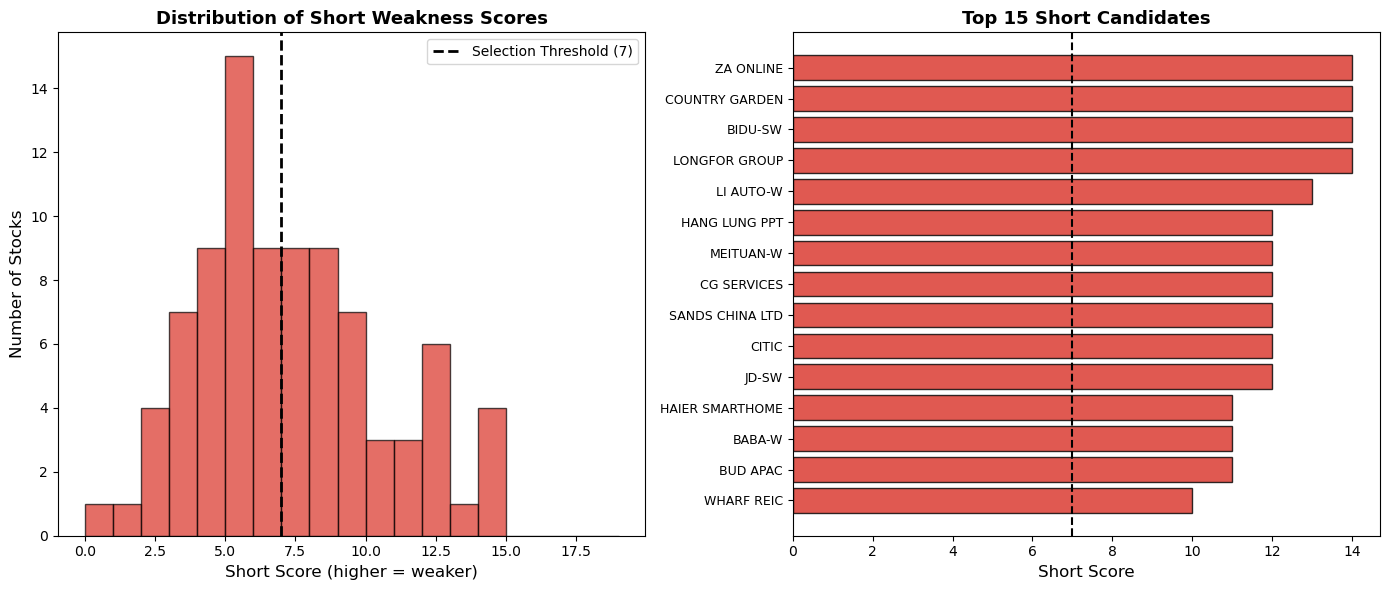

In [12]:
# ============================================================
# Visualize the short scoring distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram of short scores
ax1 = axes[0]
ax1.hist(df_short['Short_Score'], bins=range(0, 20), color='#d93025', alpha=0.7, edgecolor='black')
ax1.axvline(x=7, color='black', linestyle='--', linewidth=2, label='Selection Threshold (7)')
ax1.set_xlabel('Short Score (higher = weaker)', fontsize=12)
ax1.set_ylabel('Number of Stocks', fontsize=12)
ax1.set_title('Distribution of Short Weakness Scores', fontsize=13, fontweight='bold')
ax1.legend()

# Top 15 by score
ax2 = axes[1]
top15 = df_short_ranked.head(15)
companies = top15['Company'].apply(lambda x: str(x)[:15]).values
scores = top15['Short_Score'].values
colors = ['#d93025' if s >= 7 else '#fbbc04' for s in scores]
ax2.barh(range(len(companies)-1, -1, -1), scores, color=colors, edgecolor='black', alpha=0.8)
ax2.set_yticks(range(len(companies)-1, -1, -1))
ax2.set_yticklabels(companies, fontsize=9)
ax2.set_xlabel('Short Score', fontsize=12)
ax2.set_title('Top 15 Short Candidates', fontsize=13, fontweight='bold')
ax2.axvline(x=7, color='black', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.savefig('short_scoring_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Final Short Book Selection

In [13]:
# ============================================================
# Select top 10-15 shorts with sector diversification
# Minimum Short Score threshold: 5 (adjustable)
# ============================================================

MIN_SHORT_SCORE = 5  # Adjust if too few/many candidates
TARGET_SHORT_COUNT = 12
MAX_SECTOR_PCT = 0.40  # Allow slightly higher sector concentration for shorts
                        # (property sector may dominate weak-fundamental stocks)

# Also exclude any stocks that were selected for the Long Book
# Load long book picks if available, otherwise skip
try:
    long_picks = pd.read_csv('long_book_selected_stocks.csv', index_col=0)
    long_tickers_exclude = long_picks.index.tolist()
    print(f"Excluding {len(long_tickers_exclude)} Long Book stocks from Short candidates")
except:
    long_tickers_exclude = []
    print("Note: Long Book CSV not found. No exclusions applied.")
    print("TIP: Run the Long Book notebook first, then re-run this cell.\n")

# Filter
df_candidates = df_short_ranked[
    (df_short_ranked['Short_Score'] >= MIN_SHORT_SCORE) &
    (~df_short_ranked.index.isin(long_tickers_exclude))
].copy()

print(f"Candidates after score threshold ({MIN_SHORT_SCORE}+) and exclusions: {len(df_candidates)}")

# Apply sector diversification
selected_shorts = []
sector_count = {}

for idx, row in df_candidates.iterrows():
    sector = row.get('Sector', 'Unknown')
    current_sector_n = sector_count.get(sector, 0)
    
    if len(selected_shorts) > 0:
        max_allowed = max(2, int(len(selected_shorts) * MAX_SECTOR_PCT) + 1)
        if current_sector_n >= max_allowed and len(selected_shorts) >= 5:
            continue
    
    selected_shorts.append(idx)
    sector_count[sector] = current_sector_n + 1
    
    if len(selected_shorts) >= TARGET_SHORT_COUNT:
        break

df_final_shorts = df_candidates.loc[selected_shorts]

print(f"\n{'='*100}")
print(f"FINAL SHORT BOOK — {len(df_final_shorts)} STOCKS SELECTED")
print(f"{'='*100}")

final_cols = ['Company', 'Sector', 'Short_Score', 'ROE', 'PE_Trailing', 
              'Debt_to_Equity', 'Earnings_Growth', 'Momentum_6M_Pct',
              'Beta', 'Alpha_Annualized', 'R_Squared', 'Max_Drawdown_Pct']
final_cols = [c for c in final_cols if c in df_final_shorts.columns]

print(df_final_shorts[final_cols].to_string())

print(f"\n\nSector Distribution:")
print(df_final_shorts['Sector'].value_counts().to_string())

print(f"\nShort Signals for each pick:")
for idx, row in df_final_shorts.iterrows():
    company = str(row.get('Company', idx))[:25]
    signals = row.get('Short_Signals', '')
    print(f"  {company}: {signals}")

Excluding 12 Long Book stocks from Short candidates
Candidates after score threshold (5+) and exclusions: 65

FINAL SHORT BOOK — 12 STOCKS SELECTED
                 Company                  Sector  Short_Score      ROE PE_Trailing Debt_to_Equity  Earnings_Growth  Momentum_6M_Pct   Beta  Alpha_Annualized  R_Squared  Max_Drawdown_Pct
Ticker                                                                                                                                                                                   
6060.HK        ZA ONLINE      Financial Services           14   4.7510     15.9625        33.5880         -30.3000         -17.3997 1.6317          -11.3326     0.4890          -81.1044
2007.HK   COUNTRY GARDEN             Real Estate           14   3.4010      2.2143       340.3580              NaN         -40.3846 1.3599          -44.4945     0.2207          -97.1102
9888.HK          BIDU-SW  Communication Services           14   1.9040     64.7619        33.5060         -8

---
## 9. Short Book Visualization & Analysis

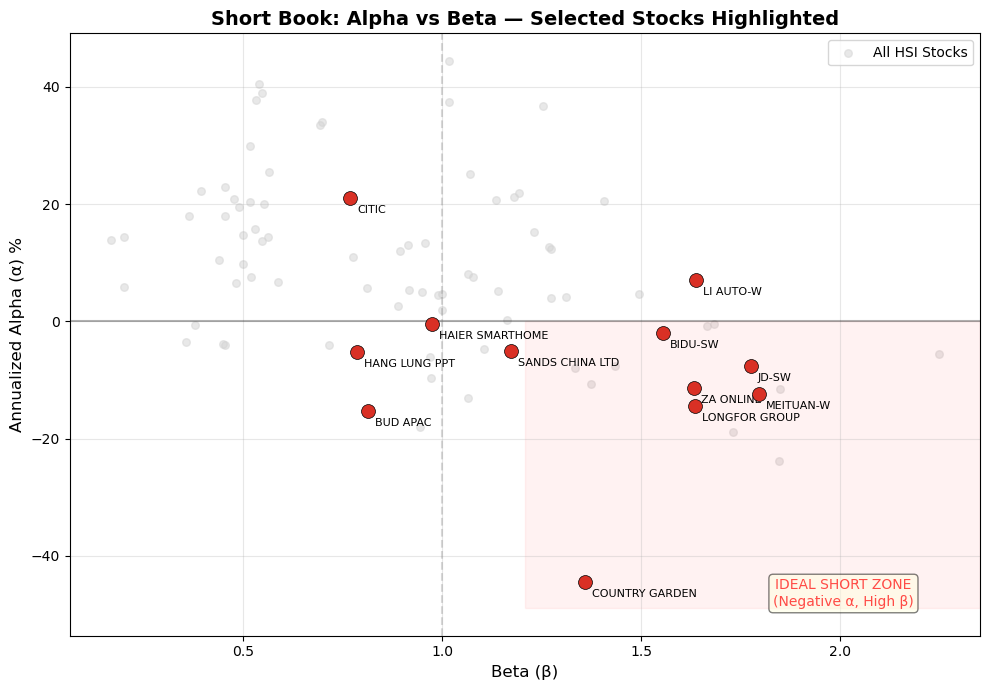

In [14]:
# ============================================================
# Chart 1: Scatter Plot — Alpha vs Beta for Short Picks
# Good shorts: NEGATIVE alpha + HIGH beta (bottom-right quadrant)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

# All HSI stocks as background
all_with_reg = df_master.dropna(subset=['Beta', 'Alpha_Annualized'])
ax.scatter(all_with_reg['Beta'], all_with_reg['Alpha_Annualized'], 
           c='lightgray', alpha=0.5, s=30, label='All HSI Stocks')

# Highlight short picks
for idx, row in df_final_shorts.iterrows():
    if pd.notna(row.get('Beta')) and pd.notna(row.get('Alpha_Annualized')):
        ax.scatter(row['Beta'], row['Alpha_Annualized'], 
                  c='#d93025', s=100, zorder=5, edgecolors='black', linewidth=0.5)
        company_name = str(row.get('Company', idx))[:15]
        ax.annotate(company_name, (row['Beta'], row['Alpha_Annualized']),
                   fontsize=8, ha='left', va='top', xytext=(5, -5),
                   textcoords='offset points')

ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.axvline(x=1, color='gray', linestyle='--', alpha=0.3)

# Shade the "ideal short" quadrant (negative alpha, high beta)
ax.axhspan(ax.get_ylim()[0], 0, xmin=0.5, alpha=0.05, color='red')

ax.set_xlabel('Beta (β)', fontsize=12)
ax.set_ylabel('Annualized Alpha (α) %', fontsize=12)
ax.set_title('Short Book: Alpha vs Beta — Selected Stocks Highlighted', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.annotate('IDEAL SHORT ZONE\n(Negative α, High β)', 
            xy=(0.85, 0.05), xycoords='axes fraction',
            fontsize=10, color='red', alpha=0.7, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.savefig('short_alpha_vs_beta.png', dpi=150, bbox_inches='tight')
plt.show()

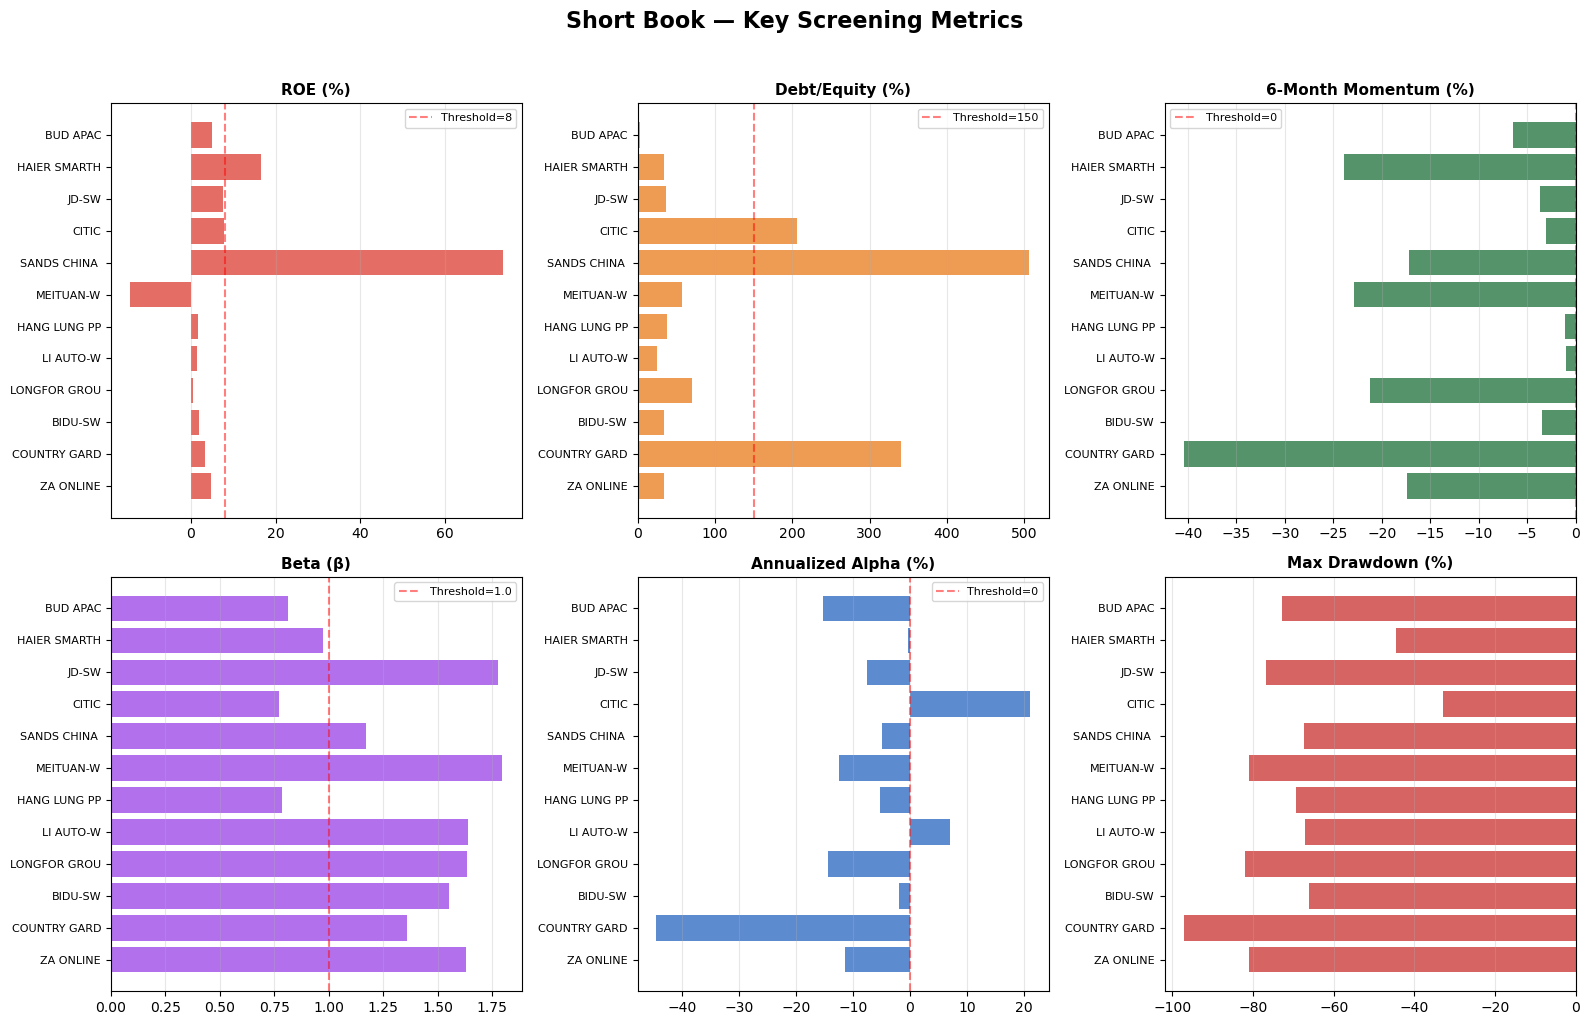

In [15]:
# ============================================================
# Chart 2: Key Metrics Comparison for Short Picks
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Short Book — Key Screening Metrics', fontsize=16, fontweight='bold', y=1.02)

metrics = [
    ('ROE', 'ROE (%)', '#d93025', 8),
    ('Debt_to_Equity', 'Debt/Equity (%)', '#e8710a', 150),
    ('Momentum_6M_Pct', '6-Month Momentum (%)', '#0d652d', 0),
    ('Beta', 'Beta (β)', '#9334e6', 1.0),
    ('Alpha_Annualized', 'Annualized Alpha (%)', '#185abc', 0),
    ('Max_Drawdown_Pct', 'Max Drawdown (%)', '#c5221f', None),
]

companies = df_final_shorts['Company'].apply(lambda x: str(x)[:12]).values

for ax, (col, title, color, threshold) in zip(axes.flatten(), metrics):
    if col in df_final_shorts.columns:
        values = pd.to_numeric(df_final_shorts[col], errors='coerce').values
        bars = ax.barh(range(len(companies)), values, color=color, alpha=0.7)
        ax.set_yticks(range(len(companies)))
        ax.set_yticklabels(companies, fontsize=8)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, axis='x', alpha=0.3)
        if threshold is not None:
            ax.axvline(x=threshold, color='red', linestyle='--', alpha=0.5, 
                      label=f'Threshold={threshold}')
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('short_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

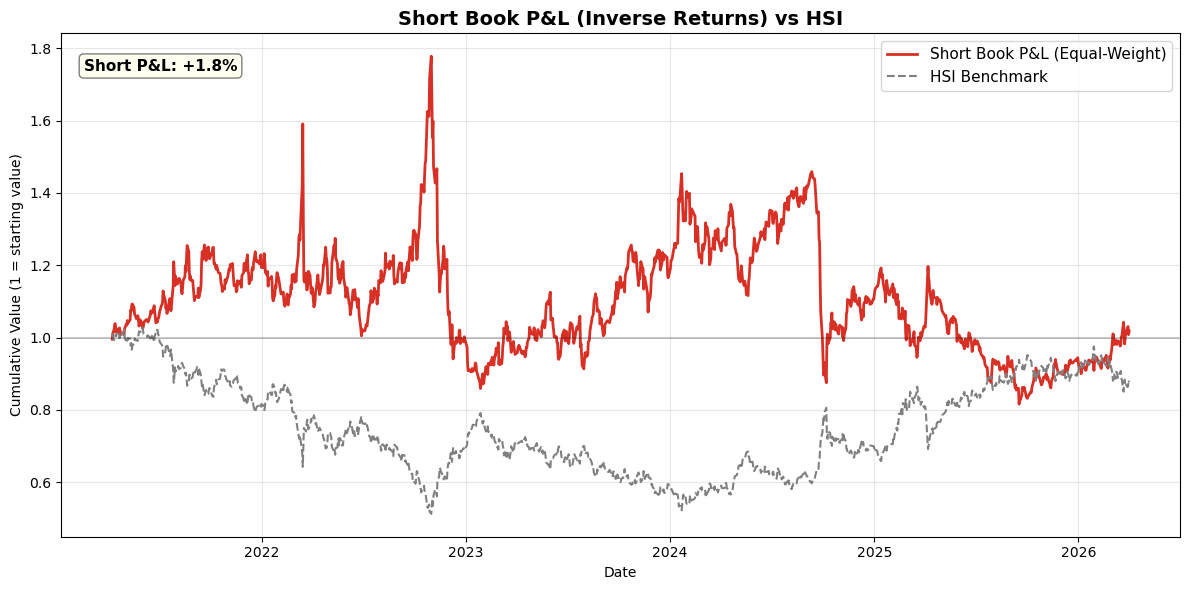


Note: Positive Short P&L means the short positions generated profit.
If Short P&L is negative, the shorted stocks went UP (loss on shorts).


In [16]:
# ============================================================
# Chart 3: Hypothetical Short Book Return vs HSI
# Short return = INVERSE of stock return (profit when stock drops)
# ============================================================

short_tickers = df_final_shorts.index.tolist()

# Equal-weight short portfolio: profit = negative of stock returns
short_daily = -daily_returns[short_tickers].mean(axis=1)  # Negative = short profit
hsi_daily = daily_returns[benchmark_ticker]

# Cumulative return
short_cum = (1 + short_daily).cumprod()
hsi_cum = (1 + hsi_daily).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(short_cum.index, short_cum.values, label='Short Book P&L (Equal-Weight)', 
        color='#d93025', linewidth=2)
ax.plot(hsi_cum.index, hsi_cum.values, label='HSI Benchmark', 
        color='gray', linewidth=1.5, linestyle='--')
ax.axhline(y=1, color='black', linestyle='-', alpha=0.2)

ax.set_title('Short Book P&L (Inverse Returns) vs HSI', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Value (1 = starting value)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

short_total = (short_cum.iloc[-1] - 1) * 100
ax.annotate(f'Short P&L: {short_total:+.1f}%', 
            xy=(0.02, 0.95), xycoords='axes fraction',
            fontsize=11, fontweight='bold', va='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.savefig('short_cumulative_pnl.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNote: Positive Short P&L means the short positions generated profit.")
print(f"If Short P&L is negative, the shorted stocks went UP (loss on shorts).")

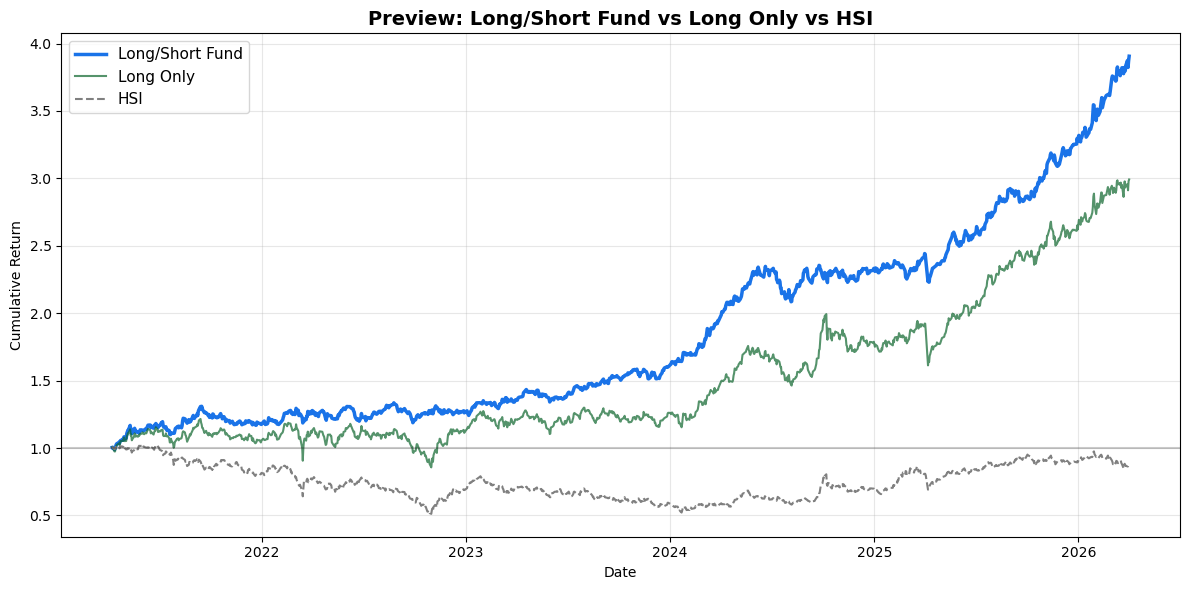

In [17]:
# ============================================================
# Chart 4: Combined Long/Short Fund vs HSI (Preview)
# This gives a preview — full backtest is in Member E's work
# ============================================================

try:
    long_picks = pd.read_csv('long_book_selected_stocks.csv', index_col=0)
    long_tickers_list = long_picks.index.tolist()
    
    long_daily_ret = daily_returns[long_tickers_list].mean(axis=1)
    short_daily_ret = -daily_returns[short_tickers].mean(axis=1)
    
    # Simple L/S: 100% long + 50% short (net 50% long)
    ls_daily = 1.0 * long_daily_ret + 0.5 * short_daily_ret
    ls_cum = (1 + ls_daily).cumprod()
    long_cum_preview = (1 + long_daily_ret).cumprod()
    hsi_cum_preview = (1 + hsi_daily).cumprod()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(ls_cum.index, ls_cum.values, label='Long/Short Fund', 
            color='#1a73e8', linewidth=2.5)
    ax.plot(long_cum_preview.index, long_cum_preview.values, label='Long Only', 
            color='#0d652d', linewidth=1.5, alpha=0.7)
    ax.plot(hsi_cum_preview.index, hsi_cum_preview.values, label='HSI', 
            color='gray', linewidth=1.5, linestyle='--')
    ax.axhline(y=1, color='black', linestyle='-', alpha=0.2)
    
    ax.set_title('Preview: Long/Short Fund vs Long Only vs HSI', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('ls_fund_preview.png', dpi=150, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f"Could not generate combined preview: {e}")
    print("Run the Long Book notebook first to generate long_book_selected_stocks.csv")

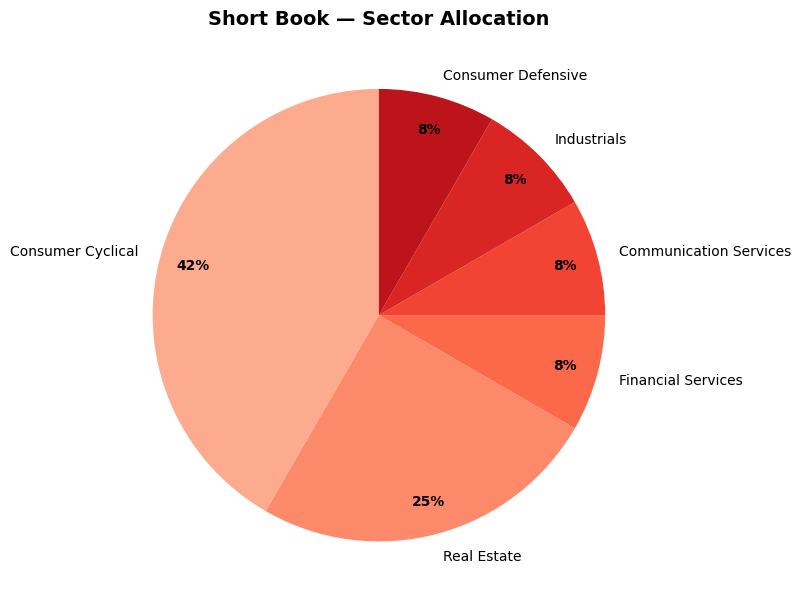

In [18]:
# ============================================================
# Chart 5: Sector Allocation Pie Chart
# ============================================================

sector_dist = df_final_shorts['Sector'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(sector_dist)))
wedges, texts, autotexts = ax.pie(sector_dist.values, labels=sector_dist.index,
                                   autopct='%1.0f%%', colors=colors,
                                   pctdistance=0.85, startangle=90)
for text in autotexts:
    text.set_fontweight('bold')
ax.set_title('Short Book — Sector Allocation', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('short_sector_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Index Futures Alternative

If individual stock shorting is too complex, you can **short HSI or HSCEI index futures** for part or all of the short book.

In [19]:
# ============================================================
# HSI Futures Information for Reference
# ============================================================

print("=" * 60)
print("HSI FUTURES CONTRACT SPECIFICATIONS")
print("=" * 60)
print(f"""
Contract:          HSI Futures
Exchange:          HKFE (Hong Kong Futures Exchange)
Contract Size:     HKD 50 × HSI Index Points
Tick Size:         1 index point = HKD 50
Margin:            ~HKD 100,000-130,000 per contract (varies)
Trading Hours:     9:15 AM - 12:00 PM, 1:00 PM - 4:30 PM (HKT)
Contract Months:   Spot, next month, next two quarter months
Settlement:        Cash settled on last trading day

MINI HSI Futures:
Contract Size:     HKD 10 × HSI Index Points (1/5 of standard)
Margin:            ~HKD 20,000-26,000 per contract

Example:
  HSI at 25,000 → 1 standard contract = 25,000 × HKD 50 = HKD 1,250,000
  To short HKD 50M of exposure → need ~40 standard contracts
  
Advantages of Index Futures for Shorts:
  - No stock borrow required
  - No dividend risk
  - High liquidity, tight spreads
  - Easy to size and adjust
  
Disadvantages:
  - No stock-specific alpha from shorts
  - Rollover costs at contract expiry
  - Cannot outperform a pure stock-selection short book
""")

print("\nRECOMMENDATION: Use a hybrid approach:")
print("  - 60-70% of short book: Individual stock shorts (from screening above)")
print("  - 30-40% of short book: HSI futures (for beta hedging)")

HSI FUTURES CONTRACT SPECIFICATIONS

Contract:          HSI Futures
Exchange:          HKFE (Hong Kong Futures Exchange)
Contract Size:     HKD 50 × HSI Index Points
Tick Size:         1 index point = HKD 50
Margin:            ~HKD 100,000-130,000 per contract (varies)
Trading Hours:     9:15 AM - 12:00 PM, 1:00 PM - 4:30 PM (HKT)
Contract Months:   Spot, next month, next two quarter months
Settlement:        Cash settled on last trading day

MINI HSI Futures:
Contract Size:     HKD 10 × HSI Index Points (1/5 of standard)
Margin:            ~HKD 20,000-26,000 per contract

Example:
  HSI at 25,000 → 1 standard contract = 25,000 × HKD 50 = HKD 1,250,000
  To short HKD 50M of exposure → need ~40 standard contracts
  
Advantages of Index Futures for Shorts:
  - No stock borrow required
  - No dividend risk
  - High liquidity, tight spreads
  - Easy to size and adjust
  
Disadvantages:
  - No stock-specific alpha from shorts
  - Rollover costs at contract expiry
  - Cannot outperform a pur

---
## 11. Export Short Book Data

In [20]:
# ============================================================
# Export final short book for use in backtesting
# ============================================================

export_cols = ['Company', 'Sector', 'Short_Score', 'Short_Signals',
               'ROE', 'PE_Trailing', 'PB_Ratio', 'Debt_to_Equity', 
               'Dividend_Yield', 'Earnings_Growth', 'Revenue_Growth',
               'Momentum_6M_Pct', 'Momentum_12M_Pct', 'Momentum_24M_Pct',
               'Beta', 'Alpha_Annualized', 'R_Squared',
               'Annualized_Vol_Pct', 'Max_Drawdown_Pct']
export_cols = [c for c in export_cols if c in df_final_shorts.columns]

df_final_shorts[export_cols].to_csv('short_book_selected_stocks.csv')
print("Exported: short_book_selected_stocks.csv")

# Export price data for selected shorts (for backtesting)
price_data[short_tickers + [benchmark_ticker]].to_csv('short_book_price_data.csv')
print("Exported: short_book_price_data.csv")

print(f"\n{'='*60}")
print(f"SHORT BOOK SUMMARY")
print(f"{'='*60}")
print(f"Stocks selected:      {len(df_final_shorts)}")
print(f"Avg Short Score:      {df_final_shorts['Short_Score'].mean():.1f} / ~19")
print(f"Avg Beta:             {pd.to_numeric(df_final_shorts['Beta'], errors='coerce').mean():.2f}")
print(f"Avg Alpha (ann.):     {pd.to_numeric(df_final_shorts['Alpha_Annualized'], errors='coerce').mean():.2f}%")
print(f"Avg R²:               {pd.to_numeric(df_final_shorts['R_Squared'], errors='coerce').mean():.2f}")
print(f"Avg ROE:              {pd.to_numeric(df_final_shorts['ROE'], errors='coerce').mean():.1f}%")
print(f"Avg 6M Momentum:      {pd.to_numeric(df_final_shorts['Momentum_6M_Pct'], errors='coerce').mean():.1f}%")
print(f"Avg Max Drawdown:     {pd.to_numeric(df_final_shorts['Max_Drawdown_Pct'], errors='coerce').mean():.1f}%")
print(f"Sectors covered:      {df_final_shorts['Sector'].nunique()}")

Exported: short_book_selected_stocks.csv
Exported: short_book_price_data.csv

SHORT BOOK SUMMARY
Stocks selected:      12
Avg Short Score:      12.6 / ~19
Avg Beta:             1.33
Avg Alpha (ann.):     -7.51%
Avg R²:               0.44
Avg ROE:              9.2%
Avg 6M Momentum:      -13.5%
Avg Max Drawdown:     -69.9%
Sectors covered:      6


---
## Notes for Member C

### What to adjust:
1. **`MIN_SHORT_SCORE`**: If fewer than 10 stocks qualify, lower from 5 to 4. If too many, raise to 7.
2. **Sector cap**: Property stocks may dominate shorts. Adjust `MAX_SECTOR_PCT` if needed.
3. **Index futures**: Decide with team what % of short book uses futures vs individual stocks.
4. **Cross-check with Long Book**: Ensure NO stock appears in both books.
5. **Qualitative overlay**: Add sector headwind notes for each short pick in your presentation slides.

### Files generated:
- `short_book_selected_stocks.csv` — Final picks with all metrics (share with Member E)
- `short_book_price_data.csv` — Historical prices (share with Member E)
- `short_scoring_distribution.png` — Score distribution for presentation
- `short_alpha_vs_beta.png` — Alpha vs Beta scatter
- `short_metrics_comparison.png` — Metrics bar charts
- `short_cumulative_pnl.png` — Short P&L chart
- `short_sector_allocation.png` — Sector pie chart
- `ls_fund_preview.png` — Combined L/S preview (if Long Book data available)